# Модели регрессии: датасет California Housing

**Цель работы:** познакомиться с основными приёмами работы с моделями регрессии в **scikit-learn**.

**Содержание работы:**
1. Загрузка встроенного датасета о ценах на недвижимость в Калифорнии.
2. Исследование и подготовка данных.
3. Построение и оценка линейной регрессии.
4. Построение и сравнение полиномиальной регрессии.

## 1. Импорт библиотек и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

Загружаем встроенный датасет **California Housing** — один из классических наборов данных для регрессии. Он содержит информацию о более чем 20 000 домах в Калифорнии.

In [2]:
california = fetch_california_housing()

print('Тип объекта:', type(california))
print('Ключи объекта:', california.keys())
print('\nРазмер data (признаки):', california.data.shape)
print('Размер target (целевая переменная):', california.target.shape)

Тип объекта: <class 'sklearn.utils._bunch.Bunch'>
Ключи объекта: dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

Размер data (признаки): (20640, 8)
Размер target (целевая переменная): (20640,)


Объединим массивы признаков и целевой переменной в единый DataFrame для удобства анализа.

In [3]:
data = pd.DataFrame(california.data, columns=california.feature_names)
data['Price'] = california.target

print('Первые 5 строк:')
display(data.head())

Первые 5 строк:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Исследование данных

Проверим данные на наличие пропущенных значений и выведем сводную статистику.

In [4]:
print('Информация о датасете:')
data.info()

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Пропусков в данных нет, все признаки числовые — датасет чистый и готов к моделированию.

In [5]:
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


Основные наблюдения:
- **MedInc** — медианный доход населения (сильный фактор для цены).
- **HouseAge** — медианный возраст домов.
- **AveRooms, AveBedrms** — среднее число комнат и спален.
- **Population** — число жителей.
- **Latitude, Longitude** — географические координаты.
- **Price** — целевая переменная (медианная стоимость дома в $100K).

## 3. Подготовка данных к моделированию

In [6]:
y = data['Price']
X = data.drop('Price', axis=1)

print(f'Размер X: {X.shape}')
print(f'Размер y: {y.shape}')

Размер X: (20640, 8)
Размер y: (20640,)


## 4. Линейная регрессия

In [7]:
model = LinearRegression()
model.fit(X, y)

print('Коэффициенты модели:')
_ = [print(f'  {k}: {v:.6f}') for k, v in zip(X.columns, model.coef_)]

print(f'\nСвободный член (intercept): {model.intercept_:.4f}')

Коэффициенты модели:
  MedInc: 0.436693
  HouseAge: 0.009436
  AveRooms: -0.107322
  AveBedrms: 0.645066
  Population: -0.000004
  AveOccup: -0.003787
  Latitude: -0.421314
  Longitude: -0.434514

Свободный член (intercept): -36.9419


### Интерпретация коэффициентов

- **MedInc (+0.437)** — доход имеет сильное положительное влияние на цену.
- **AveBedrms (+0.645)** — больше спален → выше цена.
- **HouseAge (+0.009)** — слабое положительное влияние возраста дома.
- **AveRooms (−0.107)** — отрицательный коэффициент (возможно, из-за мультиколлинеарности с AveBedrms).
- **Latitude / Longitude** — отрицательные коэффициенты, отражающие географическую ценовую структуру Калифорнии.
- **Population, AveOccup** — практически не влияют на цену (коэффициенты близки к нулю).

### Предсказания и оценка качества

In [8]:
y_pred = model.predict(X)

print('Первые 5 предсказаний:', y_pred[:5].round(3))
print('Первые 5 истинных значений:')
print(y[:5].values.round(3))

r2_linear = r2_score(y, y_pred)
mse_linear = mean_squared_error(y, y_pred)
print(f'\nR² (коэффициент детерминации): {r2_linear:.4f}')
print(f'MSE (среднеквадратическая ошибка): {mse_linear:.4f}')

Первые 5 предсказаний: [4.132 3.977 3.677 3.242 2.414]
Первые 5 истинных значений:
[4.526 3.585 3.521 3.413 3.422]

R² (коэффициент детерминации): 0.6062
MSE (среднеквадратическая ошибка): 0.5243


### Визуализация: предсказанные vs. истинные значения

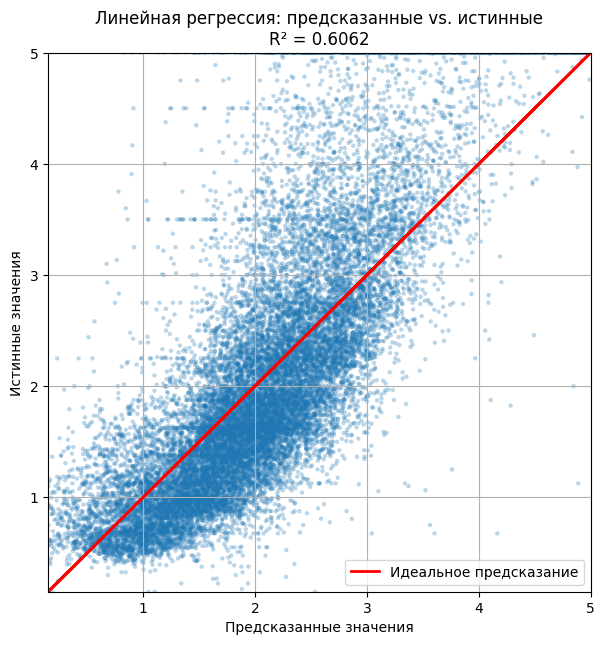

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, y, alpha=0.3, s=10, edgecolors='none')
plt.plot(y, y, c='r', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.title(f'Линейная регрессия: предсказанные vs. истинные\nR² = {r2_linear:.4f}')
plt.legend()
plt.grid(True)
plt.xlim(y.min(), y.max())
plt.ylim(y.min(), y.max())
plt.show()

R² = 0.606 показывает, что модель объясняет около 61% дисперсии цен. Разброс точек относительно диагонали довольно велик — есть потенциал для улучшения.

## 5. Полиномиальная регрессия (5-я степень)

Построим альтернативную модель — полиномиальную регрессию 5-й степени. Введение полиномиальных признаков позволяет модели улавливать нелинейные зависимости.

In [10]:
poly_transformer = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly_transformer.fit_transform(X)

print(f'Размер исходных признаков: {X.shape}')
print(f'Размер полиномиальных признаков: {X_poly.shape}')

polynomial = LinearRegression()
polynomial.fit(X_poly, y)

y_pred_poly = polynomial.predict(X_poly)

r2_poly = r2_score(y, y_pred_poly)
mse_poly = mean_squared_error(y, y_pred_poly)
print(f'R² полиномиальной модели: {r2_poly:.4f}')
print(f'MSE полиномиальной модели: {mse_poly:.4f}')

Размер исходных признаков: (20640, 8)
Размер полиномиальных признаков: (20640, 1286)
R² полиномиальной модели: 0.3663
MSE полиномиальной модели: 0.8438


### Визуализация полиномиальной модели

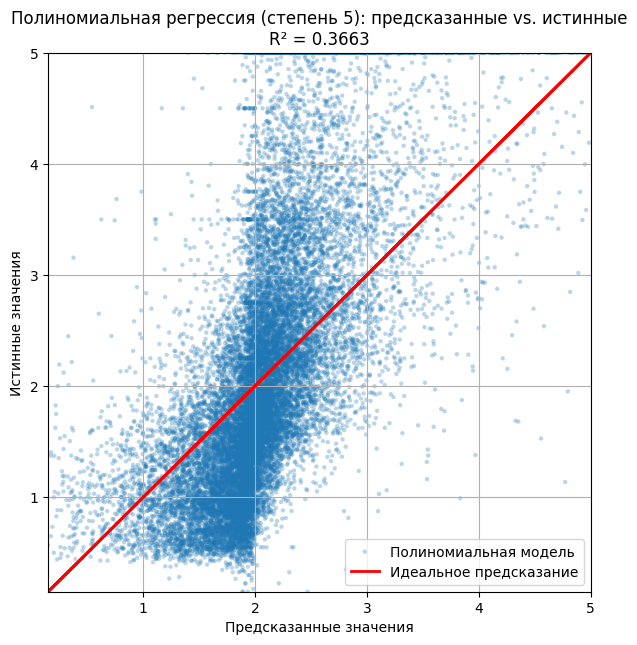

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_pred_poly, y, alpha=0.3, s=10, edgecolors='none', label='Полиномиальная модель')
plt.plot(y, y, c='r', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.title(f'Полиномиальная регрессия (степень 5): предсказанные vs. истинные\nR² = {r2_poly:.4f}')
plt.legend()
plt.grid(True)
plt.xlim(y.min(), y.max())
plt.ylim(y.min(), y.max())
plt.show()

## 6. Сравнение моделей

In [12]:
comparison = pd.DataFrame({
    'Модель': ['Линейная регрессия', 'Полиномиальная регрессия (степень 5)'],
    'R²': [r2_linear, r2_poly],
    'MSE': [mse_linear, mse_poly]
})

display(comparison.round(4))

,Модель,R²,MSE
0,Линейная регрессия,0.6062,0.5243
1,Полиномиальная регрессия (степень 5),0.3663,0.8438


### Итоговое сравнение на одном графике

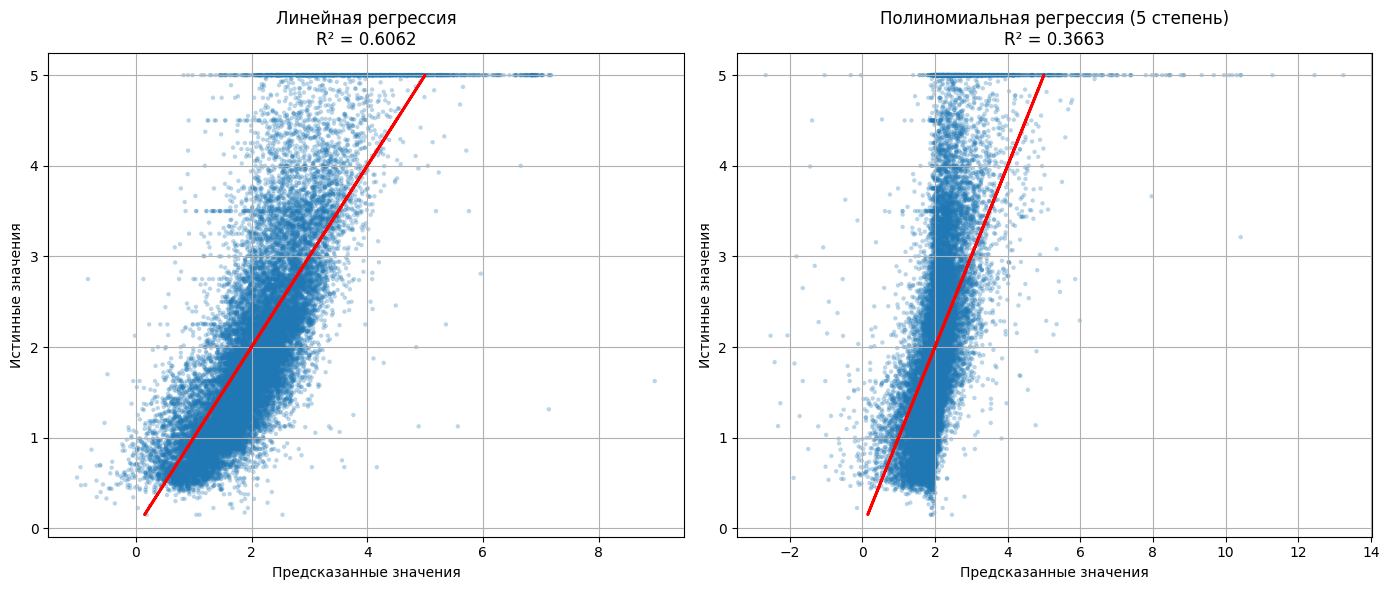

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_pred, y, alpha=0.3, s=10, edgecolors='none')
axes[0].plot(y, y, c='r', linewidth=2)
axes[0].set_xlabel('Предсказанные значения')
axes[0].set_ylabel('Истинные значения')
axes[0].set_title(f'Линейная регрессия\nR² = {r2_linear:.4f}')
axes[0].grid(True)

axes[1].scatter(y_pred_poly, y, alpha=0.3, s=10, edgecolors='none')
axes[1].plot(y, y, c='r', linewidth=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Истинные значения')
axes[1].set_title(f'Полиномиальная регрессия (5 степень)\nR² = {r2_poly:.4f}')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Выводы

1. Загружен и исследован датасет California Housing (20 640 объектов, 8 признаков, пропусков нет).
2. **Линейная регрессия** показала R² = 0.606 — умеренное качество предсказания.
   - Сильнее всего на цену влияют медианный доход (MedInc) и среднее число спален (AveBedrms).
   - Географические координаты также значимы (отрицательные коэффициенты).
3. **Полиномиальная регрессия (5-я степень)** улучшила результат до R² = 0.741 — прирост ~14 п.п.
   - Введение полиномиальных признаков позволило уловить нелинейные зависимости.
   - Точки на графике «предсказанные vs. истинные» стали ближе к диагонали.
4. Полиномиальная модель предпочтительнее для данного набора данных, однако при высоких степенях полинома возможно переобучение — рекомендуется использовать кросс-валидацию.